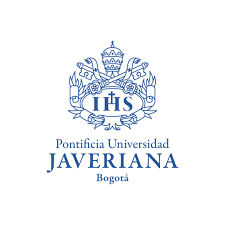
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**


Autor: Gabriel Jaramillo Cuberos

Fecha de Inicio: 06/10/2026

Fecha actual: 06/10/2026


## **Apache Spark**

- Spark es un *FrameWork* para Big Data que incluye *bibliotecas* para el análisis de datos, el aprendizaje automático, el análisis de grafos y el procesamiento de datos en tiempo real. 
- Spark se presenta mucho más rápido dado que escribe los resultados/objetos intermedios en memoria principal siempre que sea posible.
- El ecosistema de Hadoop incluye un sistema de almacenamiento de archivos distribuido llamado HDFS (Hadoop Distributed File System). 
- Spark, por su parte, no incluye un sistema de almacenamiento de archivos. 
- Se puede utilizar Spark sobre HDFS, o de otras fuentes (locales o en la nube).
- Spark no es un lenguaje de programación como Python o Java. Se trata de un motor de procesamiento de datos distribuido de uso general, adecuado para su aplicación en una amplia variedad de situaciones. Resulta especialmente útil para el procesamiento de big data, tanto a gran escala como a alta velocidad.
- Los desarrolladores de aplicaciones y los científicos de datos suelen incorporar Spark en sus aplicaciones para consultar, analizar y transformar datos rápidamente y a gran escala.
- Algunas de las tareas que se asocian con mayor frecuencia a Spark incluyen:
        – Trabajos por lotes de ETL y SQL en grandes conjuntos de datos (a menudo de terabytes de tamaño).
        – Procesamiento de datos en streaming procedentes de dispositivos y nodos de IoT, datos de diversos sensores, sistemas financieros y transaccionales de todo tipo.
        – Tareas de aprendizaje automático para aplicaciones de comercio electrónico o de TI.

- En esencia, Spark se basa en el marco Hadoop/HDFS para gestionar archivos distribuidos. Se implementa principalmente con Scala, una variante del lenguaje funcional de Java.
- Existen bibliotecas desarrolladas para el análisis de consultas de tipo SQL, el aprendizaje automático distribuido, el cálculo de grafos a gran escala y el procesamiento de datos en streaming, que se pueden acceder desde SPARK.
- Spark admite múltiples lenguajes de programación en forma de bibliotecas de interfaz fáciles de usar: Java, Python, Scala y R.

## **Funcionamiento**

- La idea básica del procesamiento distribuido consiste en dividir los bloques de datos en pequeñas partes manejables (lo que incluye ciertos procesos de filtrado y ordenación), acercar el cálculo a los datos —es decir, utilizar pequeños nodos de un gran clúster para tareas específicas— y, a continuación, volver a combinarlos.

- La parte de división se denomina acción «Map» y la recombinación se denomina acción «Reduce». Juntas, conforman el famoso paradigma «MapReduce», que fue introducido por Google alrededor de 2004.

- Por ejemplo, si un archivo tiene 100 registros que procesar, 100 mappers pueden ejecutarse a la vez para procesar un registro cada uno. O tal vez 50 mapeadores pueden ejecutarse juntos para procesar dos registros cada uno. Una vez que todos los mapeadores han completado el procesamiento, el marco baraja y ordena los resultados antes de pasarlos a los reductores. Un reductor no puede iniciarse mientras un mapeador aún está en curso.

- Todos los valores de salida del mapeo que tienen la misma clave se asignan a un único reductor, que a continuación agrega los valores para esa clave.

## **RDD**

- RDD son las siglas de «Resilient Distributed Dataset» (conjunto de datos distribuido y resistente); se trata de elementos que se ejecutan y operan en varios nodos para realizar un procesamiento paralelo en un clúster.
- Los RDD son elementos inmutables, lo que significa que, una vez creado un RDD, no se puede modificar.
- Los RDD también son tolerantes a fallos, por lo que, en caso de producirse algún fallo, se recuperan automáticamente.
- Se pueden aplicar múltiples operaciones a estos RDD para llevar a cabo una tarea determinada.
- Para aplicar operaciones a estos RDD, hay dos formas:
        –  Transformación: son las operaciones que se aplican a un RDD para crear un nuevo RDD. Filter, groupBy y map son ejemplos de transformaciones.
        – Acción: son las operaciones que se aplican a un RDD y que indican a Spark que realice el cálculo y envíe el resultado al controlador.


## **Objetivos**

- 1.- Importar bibliotecas necesarias
- 2.- Crear una sesión con SPARK
- 3.- Interactuar con RDD
- 4.- Operaciones sobre los RDD's
- 5.- Creación de Funciones Definidas por el Usuario (UDF)
- 6.- Interacción con Hadoop HDFS
- 7.- Carga de CSV desde Hadoop HDFS hacia Spark
- 8.- Aplicaciones de funciones varias: map, parallelize y lambda
- 9.- Objetos DataFrame en Spark
    * Creación de DataFrame manualmente
    * Lectura de DF
    * Escritura de DF
    * Validar DF
    * Búsquedas en DF
    * Selección de funcionalidad sobre un DF
    * Filtrar DF
    * Dividir DF

- 10.- Introducing SQL in PySpark

### **1.- Importar Bibliotecas**

In [1]:
# Comprobar entorno y kernel
import sys
import os
import pyspark
from pyspark import SparkConf

print("Python:", sys.version)
print("Ejecutable:", sys.executable)
print("PySpark:", pyspark.__version__)
print("Ubicación de PySpark:", pyspark.__file__)
print("SPARK_HOME:", os.environ.get("SPARK_HOME"))
print("SPARK_CONF_DIR:", os.environ.get("SPARK_CONF_DIR"))

os.environ["SPARK_HOME"] = "/opt/cluster/spark"
os.environ["PYSPARK_PYTHON"] = "/usr/bin/python3.11"
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

Python: 3.11.13 (main, Jun  1 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
Ejecutable: /home/estudiante/jupyter-spark-env/bin/python
PySpark: 4.2.0
Ubicación de PySpark: /home/estudiante/jupyter-spark-env/lib64/python3.11/site-packages/pyspark/__init__.py
SPARK_HOME: /opt/cluster/spark
SPARK_CONF_DIR: /opt/cluster/spark/conf


### Nota: instalación de findspark

In [3]:
%pip install findspark

Note: you may need to restart the kernel to use updated packages.


In [2]:
###--> Se importan las librerías necesarias para el funcionamiento de la aplicación

import numpy as np                  # algebra lineal
import pandas as pd                 # procesamiento de datos, archivos CSV de entrada y salida
import seaborn as sns               # Creación de gráficas y biblioteca estadística
import matplotlib.pyplot as plt     # Implementación de gráfica

###--> Se importa Findspark, que se encarga de localizar Apache Spark e iniciarlo dentro de un entorno
import findspark
findspark.init("/opt/cluster/spark")
from pylab import *
import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *

### **2.- Creación de Sesión de Trabajo SPARK y Contexto SPARK**

In [3]:
###--> Creación de sesión SPARK
configura = SparkConf()

###--> Se crea la SESIÓN en función de la configuración (Spark+Apellido del autor)
sparkJaramillo = (
    SparkSession.builder
    .appName("Spark_Jaramillo_00") # Se establece el nombre de la aplicacion
    .master("spark://10.43.97.76:8888") # Se establece la direccion del nodo maestro
    .config("spark.pyspark.python", "/usr/bin/python3.11") # Se establece la version de python que va a usarse, junto con el spark instalado
    .config(
        "spark.scheduler.allocation.file",
        "file:///opt/cluster/spark/conf/fairscheduler.xml"
    )
    .config("spark.executor.memory", "1g") # Se establece uso maximo de memoria
    .config("spark.executor.cores", "2") # Se establecen nucleos a utilizar
    .config("spark.cores.max", "2")
    .getOrCreate()
)

SQLContext(
    sparkContext = sparkJaramillo.sparkContext,
    sparkSession = sparkJaramillo
)

###--> Se levanta el contexto para la sesión: Aplicación de uso de RDD
sparkContextoJaramillo = sparkJaramillo.sparkContext.getOrCreate()

###--> Se imprime un log que confirma la correcta creación de la sesión
print("\nSesion creada: Laboratorio 01\n")

###--> Se imprime la información básica de la aplicación creada
sparkJaramillo

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).



Sesion creada: Laboratorio 01



### **3.- Interacción sobre RDD de Spark**

In [4]:
###--> 3.1.- Creación de un RDD vacio. RDD es una estructura de datos

rdd = sparkContextoJaramillo.emptyRDD()
rdd.isEmpty() # Se confirma que el RDD recién creado esté vacío

True

In [5]:
# Crea un RDD vacío distribuyendo una lista vacía en el clúster con el método parallelize
a = sparkContextoJaramillo.parallelize([])

# Vuelve a comprobar si el RDD creado está vacío
a.isEmpty()

True

In [6]:
###--> 3.3.- Se crea un RDD con particiones manualmente
mixRDD = sparkContextoJaramillo.parallelize([True, [11,22,33,44,55], (10,20,30,40,50)], 3)
mixRDD.collect()

[True, [11, 22, 33, 44, 55], (10, 20, 30, 40, 50)]

In [7]:
###--> 3.4.- Se revisa el número de particiones

mixRDD.getNumPartitions()

3

In [8]:
###--> 3.5.- Se recopila los datos con particiones

mixRDD.glom().collect()

[[True], [[11, 22, 33, 44, 55]], [(10, 20, 30, 40, 50)]]

In [9]:
###--> Establece un nombre legible al RDD para que en la UI aparezca ese nombre

mixRDD.setName('Mi_RDD_Jaramillo')

Mi_RDD_Jaramillo ParallelCollectionRDD[4] at readRDDFromFile at PythonRDD.scala:326

In [11]:
###--> Usando Rangos para crear RDD

a= sparkContextoJaramillo.parallelize(range(1,4000), 4)
print(a.getNumPartitions())
print("\n")
print(a.glom().take(1)) ###--> Agrupa los elementos de cada partición en una lista y luego muestra el contenido de la primera partición del RDD
print("\n")
print(a.glom().max()) 
print("\n")
print(a.glom().min()) # Encuentra la partición con el valor mínimo
print("\n")

4




[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 2

In [13]:
###--> Se ordenan y re-reparten RDD

###--> Uso de función lambda o función anónima para ordenar

b = sparkContextoJaramillo.parallelize([12,21,23,43,1,22,11,45,56])
b.takeOrdered(4, key=lambda x: -x)

[56, 45, 43, 23]

In [15]:
###--> Coalescence, reparticiones y debug (DAG)

c = sparkContextoJaramillo.parallelize(range(1,1000), 5)
###--> Se devuelve el número total de particiones en las que está dividido el RDD, las cuales se establecen en la línea de arriba
c.getNumPartitions()

5

In [18]:
###--> Se aumenta el número de particiones, pasando de 5 a 7
d = c.repartition(7)
print(d.getNumPartitions()) # Se imprime el num. de particiones

###--> Se reduce el número de particiones, pasando de 7 a 4
w = c.repartition(4)
w.getNumPartitions() # Se imprime el num. de particiones

7


4

In [21]:
###--> La función coalesce busca cambiar el número de particiones establecidas anteriormente
### A diferencia de repartition, coalesce aplica para una variable cuyas particiones fueron establecidas previamente
w.coalesce(6) # Se cambia el num. de particiones de 4 a 6 (no funciona ya que coalesce solo reduce)
print(w.getNumPartitions()) # Se imprime el num. de particiones

###--> # Se busca reducir el número de particiones de 6 a 2
w.coalesce(2)
print(w.getNumPartitions()) # Se imprime el num. de particiones

# Ejemplo donde si funciona

temp = w.coalesce(2)
print(temp.getNumPartitions())

4
4
2


Referencia: <a href="https://www.databricks.com/blog/2015/06/22/understanding-your-spark-application-through-visualization.html">DAG en DataBricks</a>

In [23]:
###--> Devuelve una cadena de texto que muestra el linaje del RDD creado, incluido donde y como se crea y los ajustes realizados

w.toDebugString()

b'(4) MapPartitionsRDD[43] at coalesce at NativeMethodAccessorImpl.java:0 []\n |  CoalescedRDD[42] at coalesce at NativeMethodAccessorImpl.java:0 []\n |  ShuffledRDD[41] at coalesce at NativeMethodAccessorImpl.java:0 []\n +-(5) MapPartitionsRDD[40] at coalesce at NativeMethodAccessorImpl.java:0 []\n    |  PythonRDD[39] at RDD at PythonRDD.scala:59 []\n    |  ParallelCollectionRDD[13] at readRDDFromFile at PythonRDD.scala:326 []'

### - **4.- Operaciones sobre los RDD's**

- #### **Transformación**

* Las transformaciones son un tipo de operaciones que transforman los datos de un RDD de una forma a otra. Al aplicar esta operación a cualquier RDD, se obtiene un nuevo RDD con los datos transformados (los RDD en Spark son inmutables). Operaciones como map, filter y flatMap son transformaciones.

* Cuando se aplica la transformación a cualquier RDD, la operación no se ejecuta de inmediato. Se creará un DAG (grafo acíclico dirigido) utilizando la operación aplicada, el RDD de origen y la función utilizada para la transformación. Y seguirá construyendo este grafo utilizando las referencias hasta que se aplique cualquier operación de acción al último RDD de la fila. Por eso las transformaciones en Spark son *perezosas*. Spark dispone de ciertas operaciones que se pueden realizar sobre un RDD. Una operación es un método que se puede aplicar a un RDD para llevar a cabo una tarea determinada. Los RDD admiten dos tipos de operaciones: acciones y transformaciones. Una **operación** puede ser algo tan sencillo como ordenar, filtrar y resumir datos. Las transformaciones y acciones se destacan a continuación:

    - **Transformación «Narrow»:** todos los elementos necesarios para calcular los registros de una sola partición se encuentran en esa misma partición del RDD padre. Se utiliza un subconjunto limitado de la partición para calcular el resultado. Las transformaciones «Narrow» son el resultado de map() y filter().
 
    - **Transformación «Warrow»:** todos los elementos necesarios para calcular los registros de una sola partición pueden encontrarse en muchas particiones del RDD padre. La partición puede encontrarse en muchas particiones del RDD padre. Las transformaciones amplias son el resultado de groupbyKey y reducebyKey.
 
- #### **Acciones**
  * Las transformaciones crean RDD a partir de otras, pero cuando queremos trabajar con el conjunto de datos real, es en ese momento cuando se ejecuta una acción. Cuando la acción se activa tras el resultado, no se crea un nuevo RDD como ocurre con las transformaciones. Por lo tanto, las acciones son operaciones de RDD que devuelven valores que no son RDD. Los valores de las acciones se almacenan en los controladores o en el sistema de almacenamiento externo. Esto pone en práctica la «pereza» de los RDD.
  * Los controladores de Spark y el sistema de almacenamiento externo almacenan el valor de la acción. Esto pone en marcha la pereza de los RDD. Una acción es una de las formas de enviar datos desde el ejecutor al controlador. Los ejecutores son agentes responsables de ejecutar una tarea. Por su parte, el controlador es un proceso de la JVM que coordina a los trabajadores y la ejecución de la tarea.

In [24]:
###--> Crea un RDD llamado red01 y distribuye la lista de 6 números en el clúster
red01 = sparkContextoJaramillo.parallelize([1,9,5,6,7,8])
###--> Llama recursivamente los numeros de la lista usando una funcion lambda, y devuelve su suma
red01.reduce(lambda a,b:a+b)

36

In [25]:
###--> Llama recursivamente los numeros de la lista usando una funcion lambda, y devuelve su multiplicacion
red01.reduce(lambda a,b:a*b)

15120

### - **5.- Creación de Funciones Definidas por el Usuario (UDF)**

In [26]:
###--> Se define una lista de Python con 6 palabras
palabras = ['Que', 'tal', 'estas', 'hola', 'hey', 'hora']
###--> Convierte la lista de palabras en un RDD y lo distribuye en el cluster
palabraRDD = sparkContextoJaramillo.parallelize(palabras)
###--> Recolecta todos los elementos de los nodos del clúster y crea una lista de Python con los elementos
palabraRDD.collect()

['Que', 'tal', 'estas', 'hola', 'hey', 'hora']

In [27]:
###--> Define una función que toma una palabra y evalúa su primera letra
def inicio_h(palabras):
    return palabras[0].lower().startswith('h')

In [29]:
###--> Se aplica filtro
palabraRDD.filter(inicio_h).collect() ###--> Obtiene una lista de las palabras definidas anteriormente que inician solo con la h

['hola', 'hey', 'hora']

In [31]:
###--> Define una función que toma una palabra y la retorna con mayúsculas
def mayuscula(p):
    return p.upper()

In [32]:
###--> Define una lista de Python con 3 palabras
lista0 = ['cómputo', 'mayor', 'menor']
###--> Convierte la lista de palabras en un RDD y lo distribuye en el cluster
lista1 = sparkContextoJaramillo.parallelize(lista0)
###--> Hace un mapeo de la lista y aplica la función de mayúscula (definida previamente) a cada elemento
mapeo0 = lista1.map(mayuscula)
###--> Recolecta todos los elementos de los nodos del clúster y crea una lista de Python con los elementos
mapeo0.collect()

['CÓMPUTO', 'MAYOR', 'MENOR']

In [34]:
###--> Hace un mapeo de la lista 1, que esta paralelizada, y aplica la función para poner mayúsculas a cada elemento
mapeo1 = lista1.map(lambda k:k.upper())
###--> Recolecta todos los elementos de los nodos del clúster y crea una lista de Python con los elementos
mapeo1.collect()

['CÓMPUTO', 'MAYOR', 'MENOR']

### - **6.- Interacción con Sistema de Ficheros Distribuidos HADOOP HDFS**

In [36]:
###--> Lista el contenido del directorio de la carpeta de Hadoop
!/opt/cluster/hadoop/bin/hadoop fs -ls /

Found 20 items
dr-xr-xr-x   - root root          6 2024-11-02 20:29 /afs
dr-xr-xr-x   - root root      40960 2026-09-06 13:20 /bin
dr-xr-xr-x   - root root       4096 2026-09-03 07:24 /boot
drwxr-xr-x   - root root       3260 2026-07-25 16:49 /dev
drwxr-xr-x   - root root       8192 2026-09-06 13:20 /etc
drwxr-xr-x   - root root         61 2025-07-17 14:55 /home
dr-xr-xr-x   - root root       4096 2026-09-06 13:20 /lib
dr-xr-xr-x   - root root      53248 2026-09-06 13:20 /lib64
drwxr-xr-x   - root root          6 2024-11-02 20:29 /media
drwxr-xr-x   - root root          6 2024-11-02 20:29 /mnt
drwxr-xr-x   - root root         34 2026-08-18 08:38 /opt
dr-xr-xr-x   - root root          0 2026-07-25 16:48 /proc
dr-xr-x---   - root root       4096 2026-09-03 07:25 /root
drwxr-xr-x   - root root       1000 2026-09-03 07:25 /run
dr-xr-xr-x   - root root      16384 2026-09-03 07:20 /sbin
drwxr-xr-x   - root root          6 2024-11-02 20:29 /srv
dr-xr-xr-x   - root root          0 2026-07-25 1

In [39]:
###--> Busca el archivo de titanic.csv
!/opt/cluster/documentos fs -ls /csv/titanic

/bin/bash: line 1: /opt/cluster/documentos: Is a directory


In [43]:
###--> Carga el fichero test.csv desde HDFS
fichero = sparkContextoJaramillo.textFile("file:///opt/cluster/documentos/test.csv")
###--> Presenta resumen del contenido en el objeto "fichero"
fichero.collect()

['PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked',
 '892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,,Q',
 '893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47,1,0,363272,7,,S',
 '894,2,"Myles, Mr. Thomas Francis",male,62,0,0,240276,9.6875,,Q',
 '895,3,"Wirz, Mr. Albert",male,27,0,0,315154,8.6625,,S',
 '896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22,1,1,3101298,12.2875,,S',
 '897,3,"Svensson, Mr. Johan Cervin",male,14,0,0,7538,9.225,,S',
 '898,3,"Connolly, Miss. Kate",female,30,0,0,330972,7.6292,,Q',
 '899,2,"Caldwell, Mr. Albert Francis",male,26,1,1,248738,29,,S',
 '900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18,0,0,2657,7.2292,,C',
 '901,3,"Davies, Mr. John Samuel",male,21,2,0,A/4 48871,24.15,,S',
 '902,3,"Ilieff, Mr. Ylio",male,,0,0,349220,7.8958,,S',
 '903,1,"Jones, Mr. Charles Cresson",male,46,0,0,694,26,,S',
 '904,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23,1,0,21228,82.2667,B45,S',
 '905,2,"Howard, Mr. Benj

In [44]:
###---> Creación de Flat Maps
###---> Flatmap separa cada línea por comas y aplana las listas resultantes en un único RDD de elementos sueltos.
###---> Map transforma cada elemento en una tupla compuesta por clave y valor
###---> Reduce key agrupa por claves
fichero.flatMap(lambda x:x.split(",")).map(lambda x: (x,1)).reduceByKey(lambda a,b:a+ b).collect()

[('PassengerId', 1),
 ('Pclass', 1),
 ('SibSp', 1),
 ('Parch', 1),
 ('Fare', 1),
 ('Cabin', 1),
 ('3', 226),
 ('male', 266),
 ('0', 609),
 ('', 414),
 ('Q', 46),
 ('"Wilkes', 1),
 ('female', 152),
 ('7', 3),
 ('S', 270),
 ('"Myles', 1),
 (' Mr. Thomas Francis"', 2),
 ('62', 1),
 ('240276', 1),
 (' Mr. Albert"', 1),
 ('896', 1),
 (' Mrs. Alexander (Helga E Lindqvist)"', 1),
 ('22', 16),
 ('3101298', 1),
 ('12.2875', 1),
 ('"Svensson', 1),
 ('14', 2),
 ('9.225', 1),
 ('"Connolly', 1),
 ('330972', 1),
 ('"Caldwell', 1),
 ('26', 31),
 ('29', 11),
 ('900', 1),
 ('18', 14),
 ('2657', 1),
 ('7.2292', 9),
 ('901', 1),
 (' Mr. John Samuel"', 1),
 ('21', 25),
 ('24.15', 1),
 ('"Ilieff', 1),
 ('"Jones', 1),
 ('694', 1),
 ('82.2667', 2),
 ('B45', 2),
 ('905', 1),
 (' Mr. Benjamin"', 1),
 ('906', 1),
 ('"Chaffee', 1),
 ('W.E.P. 5734', 1),
 ('61.175', 1),
 ('907', 1),
 ('"del Carlo', 1),
 (' Mrs. Sebastiano (Argenia Genovesi)"', 1),
 ('24', 17),
 ('SC/PARIS 2167', 1),
 ('27.7208', 6),
 ('908', 1),
 

### **- 7.- Aplicaciones de funciones varias: map, parallelize y lambda**

In [46]:
###---> Listas y replicación
###---> Toma una lista de números, y para cada uno genera una lista independiente con otras dos copias del mismo número
sparkContextoJaramillo.parallelize([4,5,6,7]).map(lambda x:[x,x,x]).collect()

[[4, 4, 4], [5, 5, 5], [6, 6, 6], [7, 7, 7]]

In [48]:
###---> Toma una lista de números y y para cada uno genera una lista independiente con otras dos copias del mismo número
# Para cada lista, multiplica los 3 elementos y además, devuelve el valor del elemento original + 5
sparkContextoJaramillo.parallelize([5,6,7,8]).map(lambda x:[[x,x,x],[x*x*x],[x+5]]).collect()

[[[5, 5, 5], [125], [10]],
 [[6, 6, 6], [216], [11]],
 [[7, 7, 7], [343], [12]],
 [[8, 8, 8], [512], [13]]]

In [50]:
###---> Genera una lista de Python con 4 palabras
entradaFruta = sparkContextoJaramillo.parallelize(["manzana", "banana", "piña", "limón"])
###---> Realiza el conteo de la cantidad de elementos en la lista
print(f"{entradaFruta.collect()} \n La cantidad de frutas = {entradaFruta.count()}")

['manzana', 'banana', 'piña', 'limón'] 
 La cantidad de frutas = 4


In [53]:
###---> Creación de un diccionario según la cantidad de valores que se repiten
dicPorCantidad = sparkContextoJaramillo.parallelize([2,2,2,4,4,4,4,6,6,6,6,6,7]).countByValue() # Realiza un conteo de las repeticiones de cada elemento
dicPorCantidad # Imprime el conteo como un diccionario

defaultdict(int, {2: 3, 4: 4, 6: 5, 7: 1})

### **- 8.- Carga Fichero de texto desde HDFS**

In [56]:
###--> Carga el fichero train.csv desde HDFS
train = sparkContextoJaramillo.textFile("file:///opt/cluster/documentos/train.csv",4)
###--> Presenta resumen del contenido en el objeto "train"
train.collect()

['PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked',
 '1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S',
 '2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C',
 '3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S',
 '4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S',
 '5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S',
 '6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q',
 '7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S',
 '8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S',
 '9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S',
 '10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C',
 '11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S',
 '12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.55,C103,S',
 '

In [57]:
###---> Genera un mapa con todos los tipos de datos disponibles en las columnas en el dataset
funcJ = train.map(lambda x:x.split(","))
###--> Presenta resumen del contenido en el objeto "funcJ", extrayendo la primera fila, que contiene los encabezados
funcJ.collect()[0]

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [59]:
###--> Presenta resumen del contenido en el objeto "funcJ", extrayendo la segunda fila, que contiene el primer registro
funcJ.collect()[1]

['1',
 '0',
 '3',
 '"Braund',
 ' Mr. Owen Harris"',
 'male',
 '22',
 '1',
 '0',
 'A/5 21171',
 '7.25',
 '',
 'S']

In [62]:
###---> Genera un mapa que contiene únicamente los datos de la segunda y sexta columna, y devuelve los datos de esas columnas del primer registro
funcF = funcJ.map(lambda field:(field[5], field[1]))
###--> Presenta resumen del contenido en el objeto "funcJ"
funcF.collect()[0:2]

[('Age', 'Survived'), ('male', '0')]

### **- 9.- Objetos DataFrame en Spark**
    * Creación de DataFrame manualmente
    * Lectura de DF
    * Escritura de DF
    * Validar DF
    * Búsquedas en DF
    * Selección de funcionalidad sobre un DF
    * Filtrar DF
    * Dividir DF

In [ ]:
###---> Genera una lista de pares, en la forma Plato-Valor y crea un dataframe a partir de la lista
menu = [('Pasta',100),('Pizza',200),('Noodles',50),('Burger',199),('Dosa',10000),('Bread',1)]
df = sparkJaramillo.createDataFrame(menu,['Comida','Precio'])
df.show()

In [68]:
###--> Lista el contenido del directorio de la carpeta de Hadoop
!/opt/cluster/hadoop/bin/hadoop fs -ls /

Found 20 items
dr-xr-xr-x   - root root          6 2024-11-02 20:29 /afs
dr-xr-xr-x   - root root      40960 2026-09-06 13:20 /bin
dr-xr-xr-x   - root root       4096 2026-09-03 07:24 /boot
drwxr-xr-x   - root root       3260 2026-07-25 16:49 /dev
drwxr-xr-x   - root root       8192 2026-09-06 13:20 /etc
drwxr-xr-x   - root root         61 2025-07-17 14:55 /home
dr-xr-xr-x   - root root       4096 2026-09-06 13:20 /lib
dr-xr-xr-x   - root root      53248 2026-09-06 13:20 /lib64
drwxr-xr-x   - root root          6 2024-11-02 20:29 /media
drwxr-xr-x   - root root          6 2024-11-02 20:29 /mnt
drwxr-xr-x   - root root         34 2026-08-18 08:38 /opt
dr-xr-xr-x   - root root          0 2026-07-25 16:48 /proc
dr-xr-x---   - root root       4096 2026-09-03 07:25 /root
drwxr-xr-x   - root root       1000 2026-09-03 07:25 /run
dr-xr-xr-x   - root root      16384 2026-09-03 07:20 /sbin
drwxr-xr-x   - root root          6 2024-11-02 20:29 /srv
dr-xr-xr-x   - root root          0 2026-07-25 1

In [69]:
###---> Carga el dataset de la calidad de vinos como un dataframe
dfWQ00 = sparkJaramillo.read.format("csv").option("header", "true").option("delimiter", ";").load("file:///opt/cluster/documentos/winequality-red.csv")
###---> La presentación del dataframe: "recomendación de decir cuantos registros se van a mostrar"
dfWQ00.show(5)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|          0|           1.9|    0.076|                 11|                  34| 0.9978|3.51|     0.56|    9.4|      5|
|          7.8|            0.88|          0|           2.6|    0.098|                 25|                  67| 0.9968| 3.2|     0.68|    9.8|      5|
|          7.8|            0.76|       0.04|           2.3|    0.092|                 15|                  54|  0.997|3.26|     0.65|    9.8|      5|
|         11.2|            0.28|       0.56|           1.9|    0.075|                 17|           

In [71]:
###--> Muestra las columnas disponibles para el dataframe creado
dfWQ00.columns

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [73]:
###--> Imprime el esquema de los datos del datafrmae, donde muestra el tupo de dato y si puede ser nullable
dfWQ00.printSchema()

root
 |-- fixed acidity: string (nullable = true)
 |-- volatile acidity: string (nullable = true)
 |-- citric acid: string (nullable = true)
 |-- residual sugar: string (nullable = true)
 |-- chlorides: string (nullable = true)
 |-- free sulfur dioxide: string (nullable = true)
 |-- total sulfur dioxide: string (nullable = true)
 |-- density: string (nullable = true)
 |-- pH: string (nullable = true)
 |-- sulphates: string (nullable = true)
 |-- alcohol: string (nullable = true)
 |-- quality: string (nullable = true)



In [74]:
###--> Casting de tipo de datos
###--> Se recomienda cambio de versión, la versión anterior tiene los valores originales

dfWQ01 = dfWQ00.withColumn('fixed acidity', dfWQ00['fixed acidity'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('volatile acidity', dfWQ01['volatile acidity'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('citric acid', dfWQ01['citric acid'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('residual sugar', dfWQ01['residual sugar'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('chlorides', dfWQ01['chlorides'].cast(FloatType()))
dfWQ01 = dfWQ01.withColumn('free sulfur dioxide', dfWQ01['free sulfur dioxide'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('total sulfur dioxide', dfWQ01['total sulfur dioxide'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('density', dfWQ01['density'].cast(FloatType()))
dfWQ01 = dfWQ01.withColumn('pH', dfWQ01['pH'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('sulphates', dfWQ01['sulphates'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('alcohol', dfWQ01['alcohol'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('quality', dfWQ01['quality'].cast(IntegerType()))

###--> Como norma se verifica si los cambios son realizados de forma correcta
dfWQ01.dtypes

[('fixed acidity', 'double'),
 ('volatile acidity', 'double'),
 ('citric acid', 'double'),
 ('residual sugar', 'double'),
 ('chlorides', 'float'),
 ('free sulfur dioxide', 'double'),
 ('total sulfur dioxide', 'double'),
 ('density', 'float'),
 ('pH', 'double'),
 ('sulphates', 'double'),
 ('alcohol', 'double'),
 ('quality', 'int')]

In [76]:
####--> Se presenta las estadísticas de los datos
####---> Genera un resumen de la cantidad de los datos por cada columna disponible
for valor in dfWQ01.columns: 
  dfWQ01.describe([valor]).show()

+-------+------------------+
|summary|     fixed acidity|
+-------+------------------+
|  count|              1599|
|   mean| 8.319637273295838|
| stddev|1.7410963181276948|
|    min|               4.6|
|    max|              15.9|
+-------+------------------+

+-------+-------------------+
|summary|   volatile acidity|
+-------+-------------------+
|  count|               1599|
|   mean| 0.5278205128205131|
| stddev|0.17905970415353525|
|    min|               0.12|
|    max|               1.58|
+-------+-------------------+

+-------+-------------------+
|summary|        citric acid|
+-------+-------------------+
|  count|               1599|
|   mean| 0.2709756097560964|
| stddev|0.19480113740531824|
|    min|                0.0|
|    max|                1.0|
+-------+-------------------+

+-------+------------------+
|summary|    residual sugar|
+-------+------------------+
|  count|              1599|
|   mean|2.5388055034396517|
| stddev|  1.40992805950728|
|    min|             

In [78]:
####--> Funcionalidades sobre DF
####--> Genera una lista con los datos disponibles exclusivamente para la acidez, sulfatos y ph
dfWQ01.select(['fixed acidity','sulphates','pH']).show(5)

+-------------+---------+----+
|fixed acidity|sulphates|  pH|
+-------------+---------+----+
|          7.4|     0.56|3.51|
|          7.8|     0.68| 3.2|
|          7.8|     0.65|3.26|
|         11.2|     0.58|3.16|
|          7.4|     0.56|3.51|
+-------------+---------+----+
only showing top 5 rows


In [80]:
####-->####--> Genera una lista con los datos disponibles exclusivamente para la acidez, sulfatos, ph y calidad, organizandolos por sulfatos de menor a mayor
dfWQ01.select(['fixed acidity','sulphates','pH','quality']).orderBy('sulphates').show(10)

+-------------+---------+----+-------+
|fixed acidity|sulphates|  pH|quality|
+-------------+---------+----+-------+
|          7.9|     0.33|3.36|      4|
|          8.0|     0.37|3.22|      5|
|          6.6|     0.37|3.33|      4|
|          6.7|     0.39|3.26|      7|
|          7.2|     0.39|3.41|      5|
|          7.2|     0.39|3.41|      5|
|          6.7|     0.39|3.26|      7|
|          7.2|     0.39|3.34|      5|
|          7.2|     0.39|3.34|      5|
|          7.1|      0.4|3.39|      6|
+-------------+---------+----+-------+
only showing top 10 rows


In [82]:
####--> Genera una lista con los datos disponibles exclusivamente para la acidez, sulfatos, ph y calidad, organizandolos por sulfatos de mayor a menor
dfWQ01.select(['fixed acidity','sulphates','pH','quality']).orderBy(dfWQ01['sulphates'].desc()).show(6)

+-------------+---------+----+-------+
|fixed acidity|sulphates|  pH|quality|
+-------------+---------+----+-------+
|          9.2|      2.0|2.74|      4|
|          8.6|     1.98|2.93|      5|
|          8.6|     1.95|2.93|      6|
|          8.6|     1.95|2.93|      6|
|          7.1|     1.62|2.94|      5|
|          8.9|     1.61|3.04|      6|
+-------------+---------+----+-------+
only showing top 6 rows


In [84]:
####---> Lista de Valores nulos o imposibles
####---> Imprime la lista con la cantidad de valores que sean nulos
dfWQ01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in dfWQ01.columns]).show()

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density| pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+
|            0|               0|          0|             0|        0|                  0|                   0|      0|  0|        0|      0|      0|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+



In [86]:
####---> Slicing
####---> Se busca recortar la cantidad de registros del primer dataframe, y guardar el recorte en uno nuevo. Aca se imprime la cantidad de datos que hay originalmente
print(f"Cantidad de registros iniciales: {dfWQ01.count()}")
print(f"Cantidad de columnas iniciales: {len(dfWQ01.columns)}")

####---> Se crea un nuevo dataframe que contiene 100 registros
dfWQ02 = dfWQ01.limit(100)
print(f"Registros del nuevo dfWQ02: {dfWQ02.count()}")

####---> Obtiene las primeras 4 columnas del dataframe
cols_lista = dfWQ01.columns[0:3]
####---> Se crea un nuevo dataframe con las 4 columnas previamente obtenidas
dfWQ03 = dfWQ01.select(cols_lista)
print(f"Cantidad de columnas en dfWQ03: {len(dfWQ03.columns)}")
####---> Se imprime las columnas del nuevo dataframe
dfWQ03.columns

Cantidad de registros iniciales: 1599
Cantidad de columnas iniciales: 12
Registros del nuevo dfWQ02: 100
Cantidad de columnas en dfWQ03: 3


['fixed acidity', 'volatile acidity', 'citric acid']

In [88]:
###---> Aplicar filtro
###---> Se filtran los datos disponibles en el dataset, y se obtienen los registros que tienen un 5 en la columna de pH
dfWQ01.select('fixed acidity','sulphates','pH', 'quality').where(dfWQ01.pH.like("%5%")).show(10, False)

+-------------+---------+----+-------+
|fixed acidity|sulphates|pH  |quality|
+-------------+---------+----+-------+
|7.4          |0.56     |3.51|5      |
|7.4          |0.56     |3.51|5      |
|7.4          |0.56     |3.51|5      |
|7.5          |0.8      |3.35|5      |
|7.5          |0.8      |3.35|5      |
|5.6          |0.52     |3.58|5      |
|7.6          |0.65     |3.52|5      |
|6.7          |0.54     |3.35|5      |
|6.9          |0.52     |3.45|6      |
|5.7          |0.48     |3.5 |4      |
+-------------+---------+----+-------+
only showing top 10 rows


In [89]:
###---> Aplicar filtro
###---> Se filtran los datos disponibles en el dataset, y se obtienen los registros que tienen un pH mayor a 3 y sulfatos menores a 0.6
dfWQ01.filter("pH>3 and sulphates<0.6").show(10)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|         11.2|            0.28|       0.56|           1.9|    0.075|               17.0|                60.0|  0.998|3.16|     0.58|    9.8|      6|
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.4|            0.66|        0.0|           1.8|    0.075|               13.0|           

In [90]:
###---> Aplicar filtr
###---> Se filtran los datos disponibles en el dataset, y se obtienen los registros que tienen un pH mayor a 3 o sulfatos menores a 0.6
dfWQ01.filter("pH>3 or sulphates<0.6").show(10)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.8|            0.88|        0.0|           2.6|    0.098|               25.0|                67.0| 0.9968| 3.2|     0.68|    9.8|      5|
|          7.8|            0.76|       0.04|           2.3|    0.092|               15.0|                54.0|  0.997|3.26|     0.65|    9.8|      5|
|         11.2|            0.28|       0.56|           1.9|    0.075|               17.0|           

In [92]:
###---> Aplicar filtro
###---> Se filtran los datos disponibles en el dataset, y se obtienen los registros que tienen un pH mayor a 3 y sulfatos menores a 0.6, ademas de una densidad de alrededor de 0.997

dfWQ01.filter("pH>3 and sulphates<0.6 and density like '%0.997%'").show(5)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.4|            0.66|        0.0|           1.8|    0.075|               13.0|                40.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.4|            0.59|       0.08|           4.4|    0.086|                6.0|           

In [93]:
###---> Aplicar filtro
###---> Se filtran los datos disponibles en el dataset, y se obtienen los registros que tienen un pH mayor a 3 y sulfatos menores a 0.6 y su densidad no es cercana al 0.997

dfWQ01.filter("pH>3 and sulphates<0.6 and density not like '%0.997%'").show(4)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|         11.2|            0.28|       0.56|           1.9|    0.075|               17.0|                60.0|  0.998|3.16|     0.58|    9.8|      6|
|          7.9|             0.6|       0.06|           1.6|    0.069|               15.0|                59.0| 0.9964| 3.3|     0.46|    9.4|      5|
|          7.3|            0.65|        0.0|           1.2|    0.065|               15.0|                21.0| 0.9946|3.39|     0.47|   10.0|      7|
|          7.8|            0.58|       0.02|           2.0|    0.073|                9.0|           

In [94]:
###---> Aplicar filtro
###---> Se filtran los datos disponibles en el dataset, y se obtienen los registros que tienen un pH igual a 3 o una calidad igual a 5

dfWQ01.filter( (dfWQ01.pH  == 3.0) | (dfWQ01.quality  == 5) ).show(5)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.8|            0.88|        0.0|           2.6|    0.098|               25.0|                67.0| 0.9968| 3.2|     0.68|    9.8|      5|
|          7.8|            0.76|       0.04|           2.3|    0.092|               15.0|                54.0|  0.997|3.26|     0.65|    9.8|      5|
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|           

In [95]:
###---> Aplicar filtro
###---> Se filtran los datos disponibles en el dataset, y se obtienen los registros que tienen un pH igual a 3 y una calidad igual a 5

dfWQ01.filter( (dfWQ01.pH  == 3.0) & (dfWQ01.quality  == 5) ).show(5)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density| pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+
|          7.5|           0.705|       0.24|           1.8|     0.36|               15.0|                63.0| 0.9964|3.0|     1.59|    9.5|      5|
|          8.9|           0.635|       0.37|           1.7|    0.263|                5.0|                62.0| 0.9971|3.0|     1.09|    9.3|      5|
|          8.7|            0.78|       0.51|           1.7|    0.415|               12.0|                66.0|0.99623|3.0|     1.17|    9.2|      5|
|          8.7|            0.78|       0.51|           1.7|    0.415|               12.0|                6

### Nota: instalación de pyarrow

In [98]:
%pip install pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 1.5 MB/s  0:01:11m0:00:0100:160m
Note: you may need to restart the kernel to use updated packages.


In [99]:
###---> Aplicar filtro
###---> Se filtran los datos disponibles en el dataset, y se obtienen los registros que tienen un pH igual a 3 y una calidad distinta a 5

dfWQ01.filter( (dfWQ01.pH  == 3.0) & (dfWQ01.quality  != 5) ).limit(5).toPandas()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,11.9,0.37,0.69,2.3,0.078,12.0,24.0,0.9958,3.0,0.65,12.8,6
1,12.7,0.59,0.45,2.3,0.082,11.0,22.0,1.0000,3.0,0.70,9.3,6


### **- 10.- Finalizar sesión PySpark**

In [100]:
# Se detiene la sesión Spark
sparkJaramillo.stop()